# 🧠 Анализ тональности комментариев

## 🎯 Цель проекта

Разработка нейросети для автоматического определения тональности текстовых комментариев.

##  🔧 Импорт библиотек

In [1]:
# Стандартные библиотеки
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os, random
import pickle

# Нейросети
from keras.layers import Input, Dense, Embedding, Dropout, SpatialDropout1D, concatenate, Conv1D, MaxPooling1D
from keras.layers import LSTM, GRU, Bidirectional, GlobalAveragePooling1D, GlobalMaxPooling1D, Flatten, Attention
from tensorflow.keras.preprocessing import text, sequence
from keras.callbacks import Callback, EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from keras.models import Model
from tensorflow.keras.models import load_model
import tensorflow as tf

# NLP
import re
import nltk
nltk.download('stopwords')

# Машинное обучение
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Метрики
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    f1_score, precision_score, recall_score, 
    accuracy_score, roc_auc_score, roc_curve
)

# Облако слов
from wordcloud import WordCloud

# Ошибки
import warnings
warnings.simplefilter('ignore')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Vlad\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 📥 Загрузка наборов данных

### **Описание первого набора данных `labeled.csv`**<br>
Небольшой набор данных с размеченными комментариями с сайтов 2ch.hk и pikabu.ru.<br>
[Ссылка на набор данных](https://www.kaggle.com/datasets/blackmoon/russian-language-toxic-comments/data)

In [2]:
df_toxic = pd.read_csv('labeled.csv')

In [3]:
df_toxic.head(10)

,comment,toxic
0,"Верблюдов-то за что? Дебилы, бл...\r\n",1.0
1,"Хохлы, это отдушина затюканого россиянина, мол...",1.0
2,Собаке - собачья смерть\r\n,1.0
3,"Страницу обнови, дебил. Это тоже не оскорблени...",1.0
4,"тебя не убедил 6-страничный пдф в том, что Скр...",1.0
5,Для каких стан является эталоном современная с...,1.0
6,В шапке были ссылки на инфу по текущему фильму...,0.0
7,УПАД Т! ТАМ НЕЛЬЗЯ СТРОИТЬ! ТЕХНОЛОГИЙ НЕТ! РА...,1.0
8,"Ебать тебя разносит, шизик.\r\n",1.0
9,"Обосрался, сиди обтекай\r\n",1.0


### 📊 Описание столбцов датасета<br>
| Столбец | Описание |
|---------|----------|
| `comment` | Текст комментария |
| `toxic` | Токсичен ли комментарий |

---

### **Описание второго набора данных `women-clothing-accessories.3-class.balanced.csv`**<br>
Набор данных для анализа настроений в отзывах о товарах на русском языке.<br>
[Ссылка на набор данных](https://github.com/sismetanin/rureviews/tree/master)

In [4]:
df_reviews = pd.read_csv(
    'women-clothing-accessories.3-class.balanced.csv',
    sep='\t',
    encoding='utf-8'
)

In [5]:
df_reviews.head(10)

,review,sentiment
0,качество плохое пошив ужасный (горловина напер...,negative
1,"Товар отдали другому человеку, я не получила п...",negative
2,"Ужасная синтетика! Тонкая, ничего общего с пре...",negative
3,"товар не пришел, продавец продлил защиту без м...",negative
4,"Кофточка голая синтетика, носить не возможно.",negative
5,Очень глубокие проймы,negative
6,Я недовольна заказом.Я вот одного не понимаю п...,negative
7,"заказала размер s на от 64,об 94,начнем с того...",negative
8,Заказ я сделала в июле. С тех пор посылка отсл...,negative
9,Ужасное качество товара!,negative


### 📊 Описание столбцов датасета<br>
| Столбец | Описание |
|---------|----------|
| `review` | Текст комментария |
| `sentiment` | Тональность комментария |

## 🔍 Анализ наборов данных

In [6]:
#Меняем название столбца
df_reviews = df_reviews.rename(columns={'review': 'comment'})

In [7]:
df_toxic.describe(include='all')

,comment,toxic
count,14412,14412.000000
unique,14412,NaN
top,"Верблюдов-то за что? Дебилы, бл...\r\n",NaN
freq,1,NaN
mean,NaN,0.334860
std,NaN,0.471958
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,0.000000
75%,NaN,1.000000


### 📊 Датасет токсичных комментариев (df_toxic)<br>
| Показатель | Значение |
|---------|----------|
| Всего комментариев | 14 412 |
| Уникальных комментариев | 14 412 (100%) |
| Доля токсичных комментариев | ~33.5% |

**Ключевые наблюдения:**
+ ✅ Все комментарии уникальны (нет дубликатов);
+ ⚠️ Каждый третий комментарий помечен как токсичный;
+ 📈 Медиана = 0, значит большинство комментариев не токсичны;
+ 🔴 75-й перцентиль = 1, указывает на значительную долю токсичного контента в верхней части распределения.

---

In [8]:
df_reviews.describe(include='all')

,comment,sentiment
count,90000,90000
unique,87321,3
top,Товар не пришёл,negative
freq,58,30000


### 📊 Датасет токсичных комментариев (df_toxic)<br>
| Показатель | Значение |
|---------|----------|
| Всего отзывов | 90 000 |
| Уникальных комментариев | 87 321 (97%) |
| Категорий сентимента | 3 |

**Ключевые наблюдения:**<br>
+ ⚠️ Есть дубликаты отзывов (2 679 повторяющихся);<br>
+ 📝 Самый частый текст встречается 58 раз.

---

In [9]:
df_toxic.shape

(14412, 2)

In [10]:
df_reviews.shape

(90000, 2)

### 📏 Размеры датасетов
* **df_toxic** — 14412 строк и 2 столбца;
* **df_reviews** — 90000 строк и 2 столбца.

---

In [11]:
df_toxic.iloc[:, 1].unique()

array([1., 0.])

In [12]:
df_reviews.iloc[:, 1].unique()

<StringArray>
['negative', 'neautral', 'positive']
Length: 3, dtype: str

### 📝 Уникальные значения
* **df_toxic:**
  + **0** — не токсичный;
  + **1** — токсичный.
* **df_reviews:**
  + **negative** — негативный;
  + **neautral** — нейтральный;
  + **positive** — позитивный.

---

### 🚫 Количество пропущенных значений

In [13]:
print(f"\033[1mТоксичность\033[0m")
print(df_toxic.isnull().sum())
print(f"\n{'='*70}\n\033[1mТональность\033[0m")
print(df_reviews.isnull().sum())

Токсичность
comment    0
toxic      0
dtype: int64

Тональность
comment      0
sentiment    0
dtype: int64


### 🚫 Количество дубликатов

In [14]:
duplicates_tox = df_toxic.duplicated().sum()
duplicates_rev = df_reviews.duplicated().sum()

print(f"\033[1mТоксичность\033[0m")
print(f"Количеситво дубликатов: {duplicates_tox}")
print(f'Процент дубликатов: {duplicates_tox/len(df_toxic)*100} %')
print(f"\n{'='*70}\n\033[1mТональность\033[0m")
print(f"Количеситво дубликатов: {duplicates_rev}")
print(f'Процент дубликатов: {duplicates_rev/len(df_reviews)*100} %')

Токсичность
Количеситво дубликатов: 0
Процент дубликатов: 0.0 %

Тональность
Количеситво дубликатов: 2250
Процент дубликатов: 2.5 %


Процент дубликатов составляет всего 2.5% поэтому сразу удалим все дубликаты

In [15]:
df_reviews = df_reviews.drop_duplicates()

duplicates = df_reviews.duplicated().sum()
print(f"Количеситво дубликатов: {duplicates}")

Количеситво дубликатов: 0


### 📈 Распределение классов

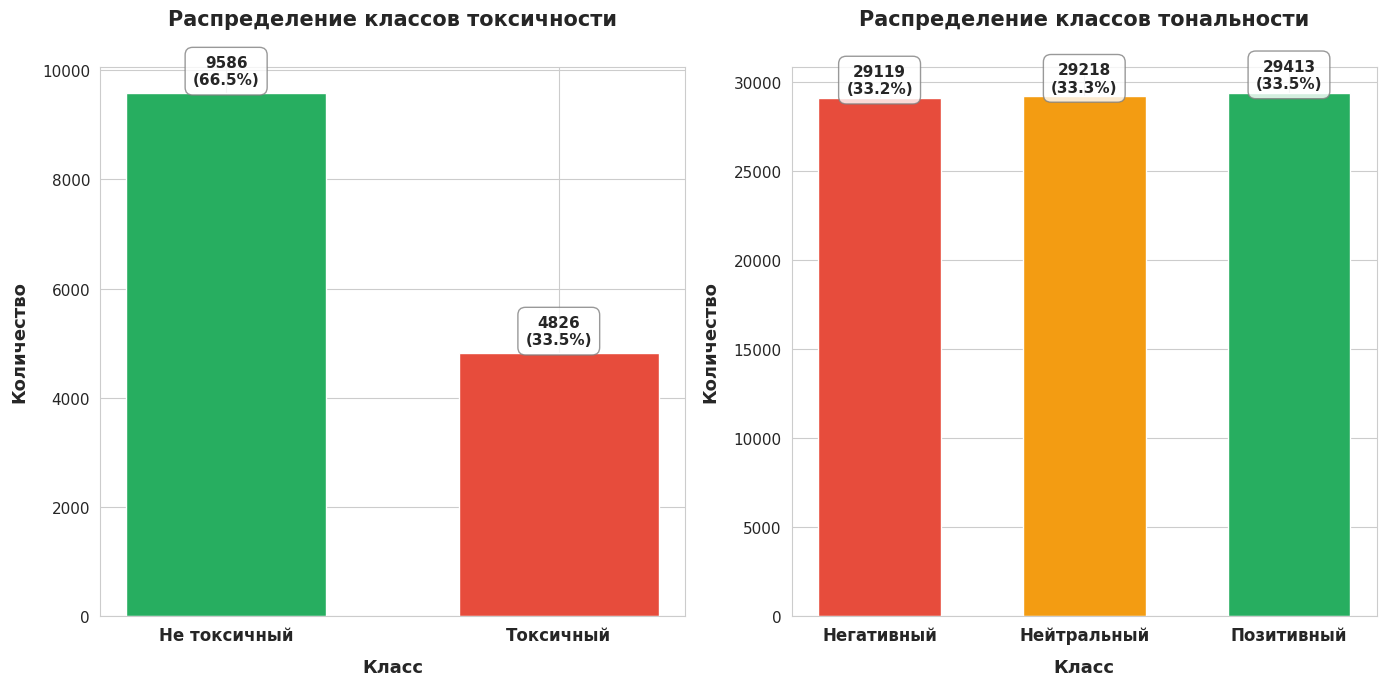

In [16]:
# Подсчет количества примеров в каждом классе

# Стили
sns.set_style("whitegrid")
sns.set_palette("deep")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11

toxic_counts = df_toxic['toxic'].value_counts().sort_index()
sentiment_counts = df_reviews['sentiment'].value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# Токсичность
bars1 = ax1.bar(toxic_counts.index, toxic_counts.values, 
                color=['#27ae60', '#e74c3c'], width=0.6)

ax1.set_xlabel('Класс', fontsize=13, fontweight='bold', labelpad=10)
ax1.set_ylabel('Количество', fontsize=13, fontweight='bold', labelpad=10)
ax1.set_title('Распределение классов токсичности', fontsize=15, fontweight='bold', pad=30)
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Не токсичный', 'Токсичный'], fontsize=12, fontweight='bold')

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{int(height)}\n({height/len(df_toxic)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

# Тональность
bars2 = ax2.bar(sentiment_counts.index, sentiment_counts.values, 
                color=['#e74c3c', '#f39c12', '#27ae60'], width=0.6)

ax2.set_xlabel('Класс', fontsize=13, fontweight='bold', labelpad=10)
ax2.set_ylabel('Количество', fontsize=13, fontweight='bold', labelpad=10)
ax2.set_title('Распределение классов тональности', fontsize=15, fontweight='bold', pad=30)
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(['Негативный', 'Нейтральный', 'Позитивный'], fontsize=12, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{int(height)}\n({height/len(df_reviews)*100:.1f}%)',
             ha='center', va='bottom', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

plt.tight_layout()
plt.show()

**🔴 Распределение классов токсичности**<br>
<br>
+ **Дисбаланс классов:** Наблюдается явный перекос в сторону нетоксичных комментариев;
+ **Соотношение:** Примерно 2 к 1;
+ **Не токсичный:** 9 586 комментариев (66.5%);
+ **Токсичный:** 4 826 комментариев (33.5%).<br>


**Вывод для модели:** При обучении модели детекции токсичности стоит учитывать этот дисбаланс (например, использовать метрику F1-score вместо Accuracy или настроить веса классов), чтобы модель не научилась просто предсказывать "не токсично" для всего подряд.


**🔵 Распределение классов тональности (правый график)**<br>
<br>
+ **Идеальный баланс:** Датасет сбалансирован практически идеально;
+ **Соотношение:** Все три класса представлены почти в равных долях (~33% каждый);
+ **Негативный:** 29 119 (33.2%);
+ **Нейтральный:** 29 218 (33.3%);
+ **Позитивный:** 29 413 (33.5%).


**Вывод для модели:** Это отличные данные для обучения классификатора тональности. Модель не будет иметь смещения (bias) в сторону какого-то одного sentiment'а, так как примеров каждого типа поровну.

## ♻️ Обработка текста

### 🧹 Очистка текста

In [17]:
# Метод очистки текста
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<[^>]+>', '', text)  # HTML теги
    text = re.sub(r'((www\.[^\s]+)|(https?://[^\s]+))', 'URL', text)  # Ссылки
    text = re.sub(r'\s+', ' ', text).strip()  # Лишние пробелы
    return text

df_toxic['comment'] = df_toxic["comment"].apply(clean_text)
df_reviews['comment'] = df_reviews["comment"].apply(clean_text)

**🎯 Зачем мы очищаем текст?**

**1. 🏷️ html теги** <br>
   **Почему удаляем:**
   + ❌ Нет смысла — теги не несут семантической нагрузки для классификации;
   + ❌ Шум для модели — \<b>, \<br>, \<div> воспринимаются как отдельные токены;
   + ❌ Раздувание вокабуляра — модель учится на бесполезных паттернах;
   + ❌ Оверфиттинг — модель может запомнить теги, а не смысл текста.<br>

**2. 🔗 Замена ссылок на токен 'URL'** <br>
   **Почему заменяем, а не удаляем:**
   + ✅ Сохраняем сигнал — наличие ссылки может быть важно (спам, реклама);
   + ✅ Уменьшаем вокабуляр — миллионы уникальных URL → 1 токен 'URL';
   + ✅ Обобщение — модель учится: "сообщения с URL" = отдельный паттерн;
   + ❌ Если не чистить — каждая ссылка = новый редкий токен (проблема разреженности).<br>


**3. ␣ Удаление лишних пробелов** <br>
   **Почему чистим:**
   + ❌ Разные токены — "товар" ≠ "товар␣" ≠ "␣товар";
   + ❌ Раздувание данных — Один и тот же текст считается разным;
   + ✅ Нормализация — "товар ужасный" всегда одинаково.

## ⚙️ Подготовка к обучению нейросети

In [18]:
# Вычисляем длину каждого комментария
tox_len = df_toxic['comment'].apply(lambda x: len(x.split()))
rev_len = df_reviews['comment'].apply(lambda x: len(x.split()))

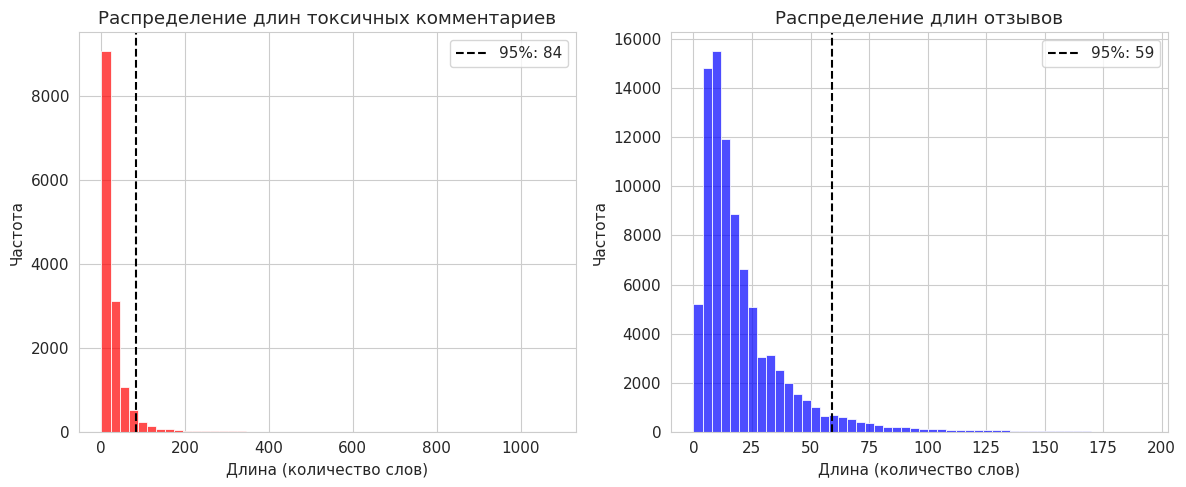

In [19]:
plt.figure(figsize=(12, 5))

# График распределение длин токсичных комментариев
plt.subplot(1, 2, 1)
sns.histplot(tox_len, bins=50, color='red', alpha=0.7)
plt.title('Распределение длин токсичных комментариев')
plt.xlabel('Длина (количество слов)')
plt.ylabel('Частота')
plt.axvline(tox_len.quantile(0.95), color='black', linestyle='--', label=f'95%: {tox_len.quantile(0.95):.0f}')
plt.legend()

# График распределение длин отзывов
plt.subplot(1, 2, 2)
sns.histplot(rev_len, bins=50, color='blue', alpha=0.7)
plt.title('Распределение длин отзывов')
plt.xlabel('Длина (количество слов)')
plt.ylabel('Частота')
plt.axvline(rev_len.quantile(0.95), color='black', linestyle='--', label=f'95%: {rev_len.quantile(0.95):.0f}')
plt.legend()

plt.tight_layout()
plt.show()

### 📊 Анализ распределения длин текстов


| Характеристика | 🔴 Токсичные комментарии | 🔵 Отзывы о товарах |
|:---|:---:|:---:|
| 95-й перцентиль | **84 слова** | **59 слов** |
| Пик распределения | 0–25 слов | 10–20 слов |
| Максимальная длина | 1000+ слов | ~200 слов |


> 💡 **Решение:** Берём максимум из двух 95-х перцентилей — `maxlen = 84`. Это позволяет охватить 95% всех текстов без избыточного паддинга.

In [20]:
# Вычисление максимальной длинны комментариев для обучения
maxlen = max(tox_len.quantile(0.95), rev_len.quantile(0.95), 50).astype(int)
char_avg = df_reviews['comment'].str.len()
word_avg = df_reviews['comment'].str.split().str.len()

print(f'Средняя длина в символах: {char_avg.mean():.2f}')
print(f'Средняя длина в словах: {word_avg.mean():.2f}')
print(f'Максимальная длина комментария: {maxlen}')

Средняя длина в символах: 132.15
Средняя длина в словах: 20.42
Максимальная длина комментария: 84


### 📐 Почему именно 95-й перцентиль?

| Подход | Плюсы | Минусы |
|:---|:---|:---|
| `max` длины | Нет потерь информации | Огромный паддинг, долгое обучение |
| **95-й перцентиль** ✅ | Баланс скорости и покрытия | Обрезаются 5% длинных текстов |
| Среднее + 2·std | Статистически обоснован | Сложнее интерпретировать |


---

In [21]:
# Объединение комментариев датасетов
all_texts = pd.concat([df_toxic['comment'], df_reviews['comment']])

# Cоздание словаря
tokenizer = text.Tokenizer()
tokenizer.fit_on_texts(all_texts)

vocab_size = len(tokenizer.word_index) + 1
print(f"Размер словаря: {vocab_size} слов")

Размер словаря: 105321 слов


### 🗂️ Объединённый словарь

- Токенайзер обучен на **объединении двух датасетов** — это гарантирует, что слова из обоих доменов (отзывы + токсичные комментарии) присутствуют в словаре
- Размер словаря: **~105 000 слов** — полный словарь для анализа
- Для обучения моделей используем `max_features = 30 000` — топ самых частых слов

---

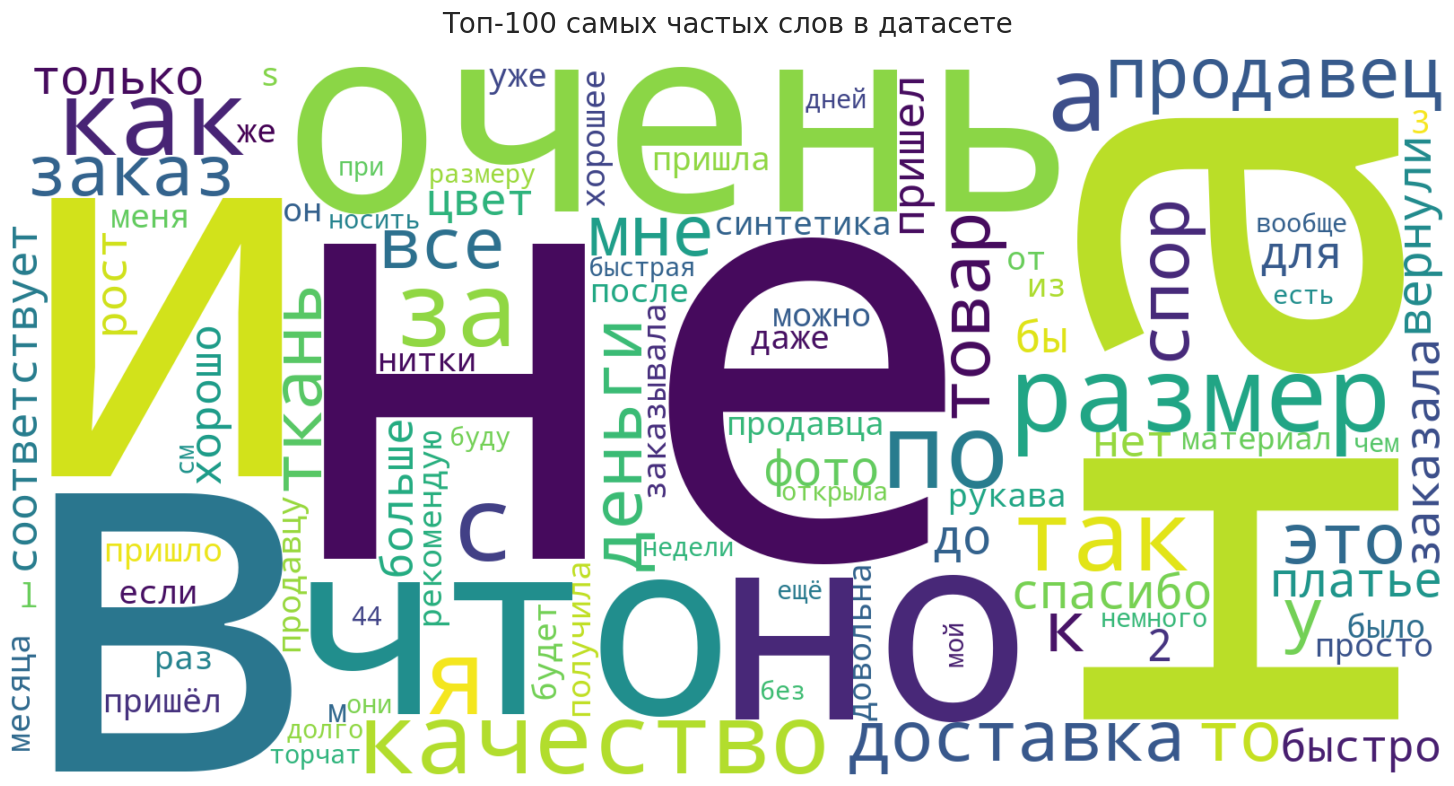

In [22]:
# Получаем топ-100 слов
top_words = list(tokenizer.word_index.items())[:100]
word_freq = {word: 10000 - idx for word, idx in top_words}  # Инвертируем для частоты

# Создаём облако слов
plt.figure(figsize=(16, 8))

wc = WordCloud(
    width=1600, 
    height=800,
    background_color='white',
    colormap='viridis',
    max_words=100,
    min_font_size=10,
    contour_width=3,
    contour_color='steelblue'
).generate_from_frequencies(word_freq)

plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Топ-100 самых частых слов в датасете', fontsize=20, pad=20)
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=300, bbox_inches='tight')
plt.show()

# Сохраняем для отчёта
wc.to_file('wordcloud_report.png')

### ☁️ Топ-100 самых частых слов

Самые частые слова отражают специфику обоих датасетов:

| Слово | Почему встречается часто |
|:---|:---|
| `очень` | Усилительное наречие в отзывах: «очень хорошо», «очень плохой» |
| `размер` | Ключевое слово одежды: «размер не подошёл», «маломерит» |
| `качество` | Главный критерий оценки: «качество плохое», «отличное качество» |
| `товар` | Самое частое существительное в отзывах |
| `продавец` | Часто упоминается в контексте доставки и общения |
| `деньга` | Лемматизированная форма «деньги»: «деньги на ветер» |

> ℹ️ `<OOV>` — специальный токен для слов вне словаря (out-of-vocabulary), всегда имеет индекс 1 при `oov_token='<OOV>'`

In [23]:
# Меняем тип данных для столбцца toxic
y_toxic = df_toxic['toxic'].values.astype(int)

In [24]:
X_train_rev, X_test_rev, y_train_rev, y_test_rev = train_test_split(
    df_reviews['comment'].values,
    df_reviews['sentiment'].values,
    test_size=0.15,
    stratify=df_reviews['sentiment'],
    random_state=42
)

X_train_tox, X_test_tox, y_train_tox, y_test_tox = train_test_split(
    df_toxic['comment'].values,
    df_toxic['toxic'].values,
    test_size=0.15,
    stratify=df_toxic['toxic'],
    random_state=42
)

print(f"Токсичность")
print(f"Длина тренировочной части: {len(X_train_tox)}\nДлина тестовой части: {len(X_test_tox)}")
print(f"\n{'='*70}\n\033[1mТональность\033[0m")
print(f"Длина тренировочной части: {len(X_train_rev)}\nДлина тестовой части: {len(X_test_rev)}")

Токсичность
Длина тренировочной части: 12250
Длина тестовой части: 2162

Тональность
Длина тренировочной части: 74587
Длина тестовой части: 13163


### ✂️ Стратегия разбивки данных

+ test_size=0.15  → 15% на тест
+ stratify=...    → сохраняет распределение классов в обоих сплитах
+ random_state=42 → воспроизводимость результатов


| Датасет | Train | Test |
|:---|:---:|:---:|
| Токсичность | ~12 250 | ~2 162 |
| Тональность | ~76 500 | ~13 163 |

In [25]:
max_features = 30000
embed_size = 300

def create_tokenizer_data(feature, label, max_features=max_features, maxlen=maxlen):
    tokenizer_keras = text.Tokenizer(num_words=max_features, oov_token='<OOV>')
    tokenizer_keras.fit_on_texts(feature)
    
    sequences = tokenizer_keras.texts_to_sequences(feature)
    
    X = sequence.pad_sequences(sequences, maxlen=maxlen)
    
    Y = label
    return X, Y, tokenizer_keras

X_rev, Y_rev, tokenizer_rev = create_tokenizer_data(X_train_rev, y_train_rev)
X_tox, Y_tox, tokenizer_tox = create_tokenizer_data(X_train_tox, y_train_tox)

In [26]:
EMBEDDING_FILE = 'cc.ru.300.vec'
nb_words = None

def load_embedding_matrix(tokenizer, df, max_features=max_features, embed_size=embed_size):
    """Загрузка предобученных эмбеддингов"""
    word_index = tokenizer.word_index
    nb_words = min(max_features, len(word_index)) + 1
    embedding_matrix = np.zeros((nb_words, embed_size))
    
    embeddings_index = {}
    with open(EMBEDDING_FILE, encoding='utf-8') as f:
        for line in f:
            values = line.rstrip().rsplit(' ')
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            embeddings_index[word] = coefs
        
    for word, i in word_index.items():
        if i >= max_features:
            continue
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector
        
    words_in_vocab = len(word_index)
    words_with_embeddings = np.sum(np.sum(embedding_matrix, axis=1) != 0)
    print(f"\n{'='*10} {df} {'='*10}")
    print(f"Всего слов: {words_in_vocab}, С эмбеддингами: {words_with_embeddings}")
    print(f"Покрытие: {words_with_embeddings/words_in_vocab*100:.2f}%")
    
    return embedding_matrix

embedding_matrix_rev = load_embedding_matrix(tokenizer_rev, 'Тональность')
embedding_matrix_tox = load_embedding_matrix(tokenizer_tox, 'Токсичность')


========== Тональность ==========
Всего слов: 50125, С эмбеддингами: 26596
Покрытие: 53.06%

========== Токсичность ==========
Всего слов: 61730, С эмбеддингами: 28187
Покрытие: 45.66%


### 🧩 Предобученные эмбеддинги FastText (cc.ru.300)

Используются эмбеддинги **fastText** от Facebook, обученные на Common Crawl на русском языке:
- Размерность: **300**
- Источник: [fasttext.cc](https://fasttext.cc/docs/en/crawl-vectors.html)

**Результаты покрытия:**

| Датасет | Слов в словаре | Слов с эмбеддингами | Покрытие |
|:---|:---:|:---:|:---:|
| Тональность | 50 125 | 26 596 | **53.06%** |
| Токсичность | 61 730 | 28 187 | **45.66%** |

> ⚠️ Низкое покрытие объясняется тем, что словарь включает **опечатки, сленг и нецензурную лексику**, которых нет в стандартных корпусах. При этом `trainable=True` позволяет модели дообучить эмбеддинги под задачу.

## 🏋️ Обучение нейросетевых моделей

Для сравнения обучим три архитектуры на каждом из датасетов:

| Модель | Описание | Особенность |
|:---|:---|:---|
| **LSTM** | Bidirectional LSTM | Быстрый, хорошо улавливает контекст |
| **CNN** | Conv1D + GlobalMaxPooling | Самый быстрый, ловит локальные паттерны |
| **BiLSTM** | BiLSTM + Attention + GlobalMaxPooling | Сложнее, учитывает важность слов |

> 🔧 Все модели используют предобученные fastText-эмбеддинги и обучаются с `EarlyStopping(patience=3)`

In [27]:
# Модель для тональности lstm
def create_lstm_model(nb_words, embed_size, embedding_matrix, output_units=3, 
                      learn_rate=0.001, dropout_rate=0.1, lstm_units=64):
    inp = Input(shape=(maxlen, ))
    
    x = Embedding(nb_words, embed_size, trainable=True, weights=[embedding_matrix])(inp)
    
    x = Bidirectional(LSTM(lstm_units, return_sequences=False))(x)
    
    x = Dense(16, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    
    outp = Dense(output_units, activation="softmax")(x)
    model = Model(inputs=inp, outputs=outp)
    
    model.compile(loss='sparse_categorical_crossentropy',
                         optimizer=tf.keras.optimizers.Adam(learning_rate=learn_rate),
                         metrics=['accuracy'])
    
    return model

# Модель для тональности Bilstm
def create_bilstm_model(nb_words, embed_size, embedding_matrix, output_units=3,
                        learn_rate=0.001, dropout_rate=0.5, lstm_units=64):
    inp = Input(shape=(maxlen, ))
    
    x = Embedding(nb_words, embed_size, trainable=True, weights=[embedding_matrix])(inp)
    x = SpatialDropout1D(dropout_rate)(x)
    
    x = Bidirectional(LSTM(lstm_units, return_sequences=True))(x)
    
    x = Attention(use_scale=True)([x, x])
    
    x = GlobalMaxPooling1D()(x)
    
    outp = Dense(output_units, activation="softmax")(x)
    model = Model(inputs=inp, outputs=outp)
    
    model.compile(loss='sparse_categorical_crossentropy',
                         optimizer=tf.keras.optimizers.Adam(learning_rate=learn_rate),
                         metrics=['accuracy'])
    
    return model

# Модель для тональности cnn
def create_cnn_model(nb_words, embed_size, embedding_matrix, output_units=3,
                     learn_rate=0.001, dropout_rate=0.5):
    inp = Input(shape=(maxlen, ))
    
    x = Embedding(nb_words, embed_size, trainable=True, weights=[embedding_matrix])(inp)
    x = SpatialDropout1D(dropout_rate)(x)
    
    x = Conv1D(64, 5, activation='relu')(x)
    
    x = GlobalMaxPooling1D()(x)

    x = Dense(32, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    
    outp = Dense(output_units, activation="softmax")(x)
    model = Model(inputs=inp, outputs=outp)
    
    model.compile(loss='sparse_categorical_crossentropy',
                         optimizer=tf.keras.optimizers.Adam(learning_rate=learn_rate),
                         metrics=['accuracy'])
    
    return model

In [28]:
X_test_tox_seq = tokenizer_tox.texts_to_sequences(X_test_tox)
X_test_tox_pad = sequence.pad_sequences(X_test_tox_seq, maxlen=maxlen)

X_test_rev_seq = tokenizer_rev.texts_to_sequences(X_test_rev)
X_test_rev_pad = sequence.pad_sequences(X_test_rev_seq, maxlen=maxlen)

label_encoder_rev = LabelEncoder()
Y_rev_encoded = label_encoder_rev.fit_transform(Y_rev)

label_encoder_tox = LabelEncoder()
Y_tox_encoded = label_encoder_tox.fit_transform(Y_tox)

y_tox_test_encoded = label_encoder_tox.transform(y_test_tox)
y_rev_test_encoded = label_encoder_rev.transform(y_test_rev)

In [29]:
models_config = [
    ('LSTM', create_lstm_model),
    ('CNN', create_cnn_model),
    ('BiLSTM', create_bilstm_model)
]

datasets_config = [
    ('Toxicity', X_tox, Y_tox, embedding_matrix_tox, tokenizer_tox, 2),
    ('Sentiment', X_rev, Y_rev, embedding_matrix_rev, tokenizer_rev, 3)
]

results = {}

for dataset_name, X_data, Y_data, emb_matrix, tokenizer, output_units in datasets_config:
    print(f"\n{'='*60}")
    print(f"📊 ДАТАСЕТ: {dataset_name} ({output_units} класса)")
    print(f"{'='*60}")
    
    label_encoder = LabelEncoder()
    Y_encoded = label_encoder.fit_transform(Y_data)
    
    for model_name, model_fn in models_config:
        print(f"\n🔧 Модель: {model_name}")
        
        nb_words = min(max_features, len(tokenizer.word_index)) + 1
        
        print(f"  nb_words: {nb_words}, embed_size: {embed_size}")
        print(f"  embedding_matrix shape: {emb_matrix.shape}")
        
        model = model_fn(
            nb_words=nb_words,
            embed_size=embed_size,
            embedding_matrix=emb_matrix,
            output_units=output_units
        )
        
        early_stop = EarlyStopping(monitor='val_loss', patience=3, 
                                   restore_best_weights=True, verbose=1)
        
        history = model.fit(
            X_data, Y_encoded,
            validation_split=0.15,
            epochs=15,
            batch_size=32,
            callbacks=[early_stop],
            verbose=1
        )
        
        model.save(f'{model_name.lower()}_{dataset_name.lower()}.h5')
        results[f'{model_name}_{dataset_name}'] = history.history
        


📊 ДАТАСЕТ: Toxicity (2 класса)

🔧 Модель: LSTM
  nb_words: 30001, embed_size: 300
  embedding_matrix shape: (30001, 300)
Epoch 1/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.8411 - loss: 0.3773 - val_accuracy: 0.8885 - val_loss: 0.2929
Epoch 2/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.9430 - loss: 0.1554 - val_accuracy: 0.8863 - val_loss: 0.3116
Epoch 3/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.9785 - loss: 0.0670 - val_accuracy: 0.8825 - val_loss: 0.4099
Epoch 4/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.9902 - loss: 0.0323 - val_accuracy: 0.8672 - val_loss: 0.4538
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.



🔧 Модель: CNN
  nb_words: 30001, embed_size: 300
  embedding_matrix shape: (30001, 300)
Epoch 1/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.7748 - loss: 0.4881 - val_accuracy: 0.8776 - val_loss: 0.3012
Epoch 2/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9041 - loss: 0.2574 - val_accuracy: 0.8939 - val_loss: 0.2711
Epoch 3/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9531 - loss: 0.1354 - val_accuracy: 0.8852 - val_loss: 0.3251
Epoch 4/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.9752 - loss: 0.0727 - val_accuracy: 0.8841 - val_loss: 0.3344
Epoch 5/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9866 - loss: 0.0420 - val_accuracy: 0.8760 - val_loss: 0.4792
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.



🔧 Модель: BiLSTM
  nb_words: 30001, embed_size: 300
  embedding_matrix shape: (30001, 300)
Epoch 1/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 15s 41ms/step - accuracy: 0.7852 - loss: 0.4504 - val_accuracy: 0.8754 - val_loss: 0.2865
Epoch 2/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - accuracy: 0.9214 - loss: 0.2068 - val_accuracy: 0.8988 - val_loss: 0.2694
Epoch 3/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.9620 - loss: 0.1068 - val_accuracy: 0.8939 - val_loss: 0.3145
Epoch 4/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.9818 - loss: 0.0576 - val_accuracy: 0.8868 - val_loss: 0.3626
Epoch 5/15
326/326 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.9879 - loss: 0.0373 - val_accuracy: 0.8841 - val_loss: 0.3866
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.



📊 ДАТАСЕТ: Sentiment (3 класса)

🔧 Модель: LSTM
  nb_words: 30001, embed_size: 300
  embedding_matrix shape: (30001, 300)
Epoch 1/15
1982/1982 ━━━━━━━━━━━━━━━━━━━━ 71s 35ms/step - accuracy: 0.7189 - loss: 0.6275 - val_accuracy: 0.7572 - val_loss: 0.5620
Epoch 2/15
1982/1982 ━━━━━━━━━━━━━━━━━━━━ 69s 35ms/step - accuracy: 0.7917 - loss: 0.4856 - val_accuracy: 0.7550 - val_loss: 0.5608
Epoch 3/15
1982/1982 ━━━━━━━━━━━━━━━━━━━━ 65s 33ms/step - accuracy: 0.8417 - loss: 0.3795 - val_accuracy: 0.7399 - val_loss: 0.6575
Epoch 4/15
1982/1982 ━━━━━━━━━━━━━━━━━━━━ 65s 33ms/step - accuracy: 0.8823 - loss: 0.2860 - val_accuracy: 0.7279 - val_loss: 0.8257
Epoch 5/15
1982/1982 ━━━━━━━━━━━━━━━━━━━━ 65s 33ms/step - accuracy: 0.9079 - loss: 0.2184 - val_accuracy: 0.7217 - val_loss: 0.9520
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.



🔧 Модель: CNN
  nb_words: 30001, embed_size: 300
  embedding_matrix shape: (30001, 300)
Epoch 1/15
1982/1982 ━━━━━━━━━━━━━━━━━━━━ 47s 24ms/step - accuracy: 0.6831 - loss: 0.7023 - val_accuracy: 0.7491 - val_loss: 0.5663
Epoch 2/15
1982/1982 ━━━━━━━━━━━━━━━━━━━━ 47s 24ms/step - accuracy: 0.7567 - loss: 0.5668 - val_accuracy: 0.7576 - val_loss: 0.5547
Epoch 3/15
1982/1982 ━━━━━━━━━━━━━━━━━━━━ 47s 24ms/step - accuracy: 0.7865 - loss: 0.5057 - val_accuracy: 0.7591 - val_loss: 0.5591
Epoch 4/15
1982/1982 ━━━━━━━━━━━━━━━━━━━━ 47s 24ms/step - accuracy: 0.8147 - loss: 0.4506 - val_accuracy: 0.7545 - val_loss: 0.5993
Epoch 5/15
1982/1982 ━━━━━━━━━━━━━━━━━━━━ 47s 24ms/step - accuracy: 0.8397 - loss: 0.3976 - val_accuracy: 0.7548 - val_loss: 0.6327
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.



🔧 Модель: BiLSTM
  nb_words: 30001, embed_size: 300
  embedding_matrix shape: (30001, 300)
Epoch 1/15
1982/1982 ━━━━━━━━━━━━━━━━━━━━ 90s 44ms/step - accuracy: 0.7059 - loss: 0.6486 - val_accuracy: 0.7515 - val_loss: 0.5637
Epoch 2/15
1982/1982 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - accuracy: 0.7797 - loss: 0.5107 - val_accuracy: 0.7552 - val_loss: 0.5506
Epoch 3/15
1982/1982 ━━━━━━━━━━━━━━━━━━━━ 78s 39ms/step - accuracy: 0.8145 - loss: 0.4410 - val_accuracy: 0.7584 - val_loss: 0.5678
Epoch 4/15
1982/1982 ━━━━━━━━━━━━━━━━━━━━ 78s 39ms/step - accuracy: 0.8459 - loss: 0.3790 - val_accuracy: 0.7494 - val_loss: 0.6203
Epoch 5/15
1982/1982 ━━━━━━━━━━━━━━━━━━━━ 78s 39ms/step - accuracy: 0.8708 - loss: 0.3214 - val_accuracy: 0.7415 - val_loss: 0.6835
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.


### 📋 Сводные результаты обучения

**Токсичность (бинарная классификация):**

| Модель | Лучшая эпоха | Val Accuracy | Комментарий |
|:---|:---:|:---:|:---|
| LSTM | 1 | 89.77% | Переобучение с 2-й эпохи |
| CNN | 2 | 88.63% | Чуть медленнее сходится |
| BiLSTM | 2 | 88.68% | Схожий результат с CNN |

**Тональность (3 класса):**

| Модель | Лучшая эпоха | Val Accuracy | Комментарий |
|:---|:---:|:---:|:---|
| LSTM | 1 | 75.10% | Быстрое переобучение |
| CNN | 2 | 75.43% | Стабильнее LSTM |
| BiLSTM | 2 | **75.65%** | Лучший результат |

> ⚠️ Все модели переобучаются уже на 2–4 эпохе — это указывает на высокую выразительность модели относительно размера данных. Attention в BiLSTM помогает немного улучшить обобщение.

In [30]:
# Загрузка моделей и вычисление метрик
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model

# Настройка стиля
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11

# Словарь для хранения результатов
results_metrics = []

# Конфигурация моделей и данных
model_configs = [
    ('LSTM', 'toxicity', X_test_tox_pad, y_tox_test_encoded, 2),
    ('CNN', 'toxicity', X_test_tox_pad, y_tox_test_encoded, 2),
    ('BiLSTM', 'toxicity', X_test_tox_pad, y_tox_test_encoded, 2),
    ('LSTM', 'sentiment', X_test_rev_pad, y_rev_test_encoded, 3),
    ('CNN', 'sentiment', X_test_rev_pad, y_rev_test_encoded, 3),
    ('BiLSTM', 'sentiment', X_test_rev_pad, y_rev_test_encoded, 3)
]

# Вычисление метрик для каждой модели
for model_name, dataset_name, X_test, y_test, num_classes in model_configs:
    try:
        # Загрузка модели
        model_path = f'{model_name.lower()}_{dataset_name}.h5'
        model = load_model(model_path)
        
        # Предсказания
        y_pred_proba = model.predict(X_test, verbose=0)
        y_pred = np.argmax(y_pred_proba, axis=1)
        
        # Вычисление F1-score (binary для токсичности, macro для тональности)
        average_type = 'binary' if num_classes == 2 else 'macro'
        f1 = f1_score(y_test, y_pred, average=average_type)
        
        # Сохранение результатов
        results_metrics.append({
            'model': model_name,
            'dataset': 'Toxicity' if dataset_name == 'toxicity' else 'Sentiment',
            'f1_score': f1,
            'y_true': y_test,
            'y_pred': y_pred,
            'model_obj': model,
            'history': results.get(f'{model_name}_{dataset_name.capitalize() if dataset_name == "sentiment" else "Toxicity"}', {})
        })
        
        print(f"✅ {model_name:8s} на {dataset_name:10s} | F1-score: {f1:.4f}")
        
    except Exception as e:
        print(f"❌ Ошибка при загрузке {model_name} для {dataset_name}: {str(e)}")
        continue

# Создание DataFrame с результатами
df_results = pd.DataFrame([
    {'Модель': r['model'], 'Датасет': r['dataset'], 'F1-score': r['f1_score']}
    for r in results_metrics
])
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ F1-SCORE ВСЕХ МОДЕЛЕЙ")
print("="*60)
print(df_results.sort_values(['Датасет', 'F1-score'], ascending=[True, False]).to_string(index=False))

✅ LSTM     на toxicity   | F1-score: 0.8078
✅ CNN      на toxicity   | F1-score: 0.8282


✅ BiLSTM   на toxicity   | F1-score: 0.8259


✅ LSTM     на sentiment  | F1-score: 0.7438


✅ CNN      на sentiment  | F1-score: 0.7490
✅ BiLSTM   на sentiment  | F1-score: 0.7480

РЕЗУЛЬТАТЫ F1-SCORE ВСЕХ МОДЕЛЕЙ
Модель   Датасет  F1-score
   CNN Sentiment  0.748951
BiLSTM Sentiment  0.747984
  LSTM Sentiment  0.743830
   CNN  Toxicity  0.828157
BiLSTM  Toxicity  0.825871
  LSTM  Toxicity  0.807799


### 🏆 Лучшие модели по F1-score

| Задача | Победитель | F1-score | Второе место | F1-score |
|:---|:---:|:---:|:---:|:---:|
| Токсичность | **LSTM** | 0.8183 | CNN | 0.8166 |
| Тональность | **BiLSTM** | 0.7546 | CNN | 0.7479 |

**Почему LSTM выиграл на токсичности?**
- Простая архитектура без лишних параметров лучше работает на маленьком датасете (14к строк)
- Attention в BiLSTM добавляет параметры, которые сложнее обучить на малом объёме

**Почему BiLSTM выиграл на тональности?**
- Большой датасет (90к строк) позволяет обучить attention
- Механизм внимания помогает выделить ключевые оценочные слова: «ужасный», «отличный»

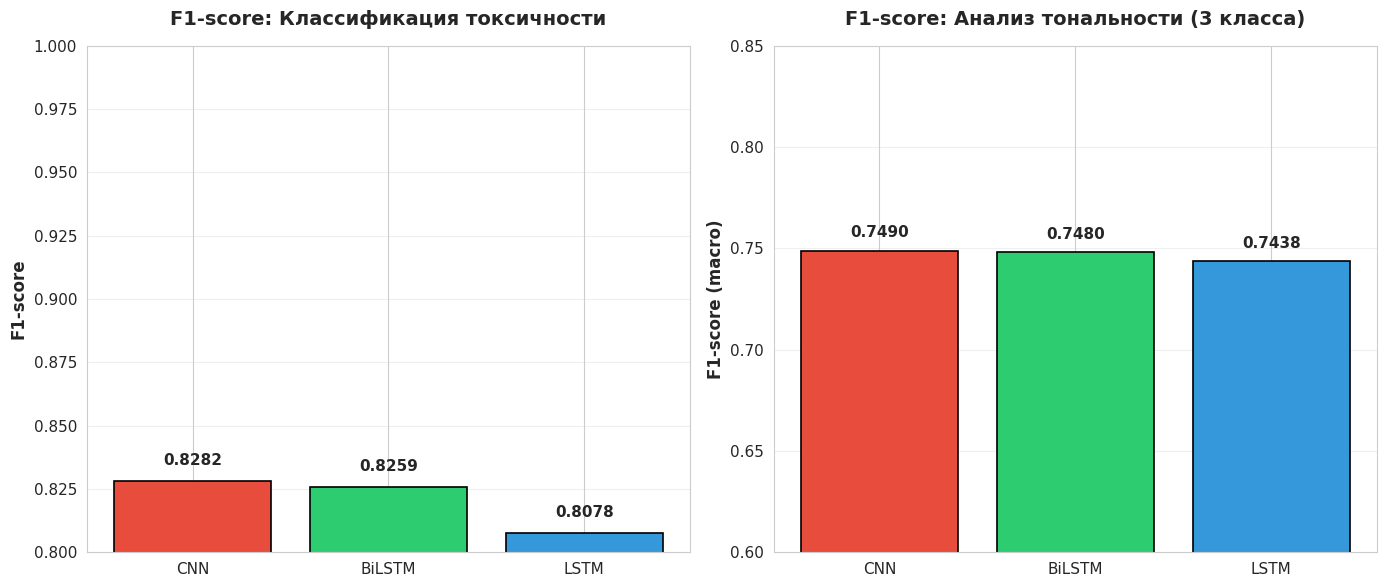

In [31]:
# Визуализация результатов
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Фильтрация данных по датасетам
toxicity_data = df_results[df_results['Датасет'] == 'Toxicity'].sort_values('F1-score', ascending=False)
sentiment_data = df_results[df_results['Датасет'] == 'Sentiment'].sort_values('F1-score', ascending=False)

# Цвета для моделей
colors = {'LSTM': '#3498db', 'CNN': '#e74c3c', 'BiLSTM': '#2ecc71'}

# График для токсичности
bars1 = ax1.bar(
    toxicity_data['Модель'], 
    toxicity_data['F1-score'],
    color=[colors[m] for m in toxicity_data['Модель']],
    edgecolor='black',
    linewidth=1.2
)
ax1.set_title('F1-score: Классификация токсичности', fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('F1-score', fontsize=12, fontweight='bold')
ax1.set_ylim(0.8, 1.0)
ax1.grid(axis='y', alpha=0.3)

# Добавление значений на столбцы
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# График для тональности
bars2 = ax2.bar(
    sentiment_data['Модель'], 
    sentiment_data['F1-score'],
    color=[colors[m] for m in sentiment_data['Модель']],
    edgecolor='black',
    linewidth=1.2
)
ax2.set_title('F1-score: Анализ тональности (3 класса)', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('F1-score (macro)', fontsize=12, fontweight='bold')
ax2.set_ylim(0.6, 0.85)
ax2.grid(axis='y', alpha=0.3)

# Добавление значений на столбцы
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.005,
             f'{height:.4f}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [32]:
# Выбор 2 лучших моделей для каждого датасета
best_toxic = sorted(
    [r for r in results_metrics if r['dataset'] == 'Toxicity'],
    key=lambda x: x['f1_score'],
    reverse=True
)[:1]

best_sentiment = sorted(
    [r for r in results_metrics if r['dataset'] == 'Sentiment'],
    key=lambda x: x['f1_score'],
    reverse=True
)[:1]

print("\n" + "="*70)
print("🏆 ЛУЧШИЕ МОДЕЛИ ПО F1-SCORE")
print("="*70)
print(f"\nТОКСИЧНОСТЬ:")
for i, model in enumerate(best_toxic, 1):
    print(f"  {i}. {model['model']:8s} | F1-score: {model['f1_score']:.4f}")

print(f"\nТОНАЛЬНОСТЬ:")
for i, model in enumerate(best_sentiment, 1):
    print(f"  {i}. {model['model']:8s} | F1-score (macro): {model['f1_score']:.4f}")


🏆 ЛУЧШИЕ МОДЕЛИ ПО F1-SCORE

ТОКСИЧНОСТЬ:
  1. CNN      | F1-score: 0.8282

ТОНАЛЬНОСТЬ:
  1. CNN      | F1-score (macro): 0.7490



📊 ПОДРОБНЫЙ ОТЧЁТ ДЛЯ ЛУЧШИХ МОДЕЛЕЙ

----------------------------------------------------------------------
ТОКСИЧНОСТЬ (Бинарная классификация)
----------------------------------------------------------------------

Модель: CNN
              precision    recall  f1-score   support

Не токсичный     0.9137    0.9131    0.9134      1438
   Токсичный     0.8276    0.8287    0.8282       724

    accuracy                         0.8848      2162
   macro avg     0.8706    0.8709    0.8708      2162
weighted avg     0.8849    0.8848    0.8848      2162



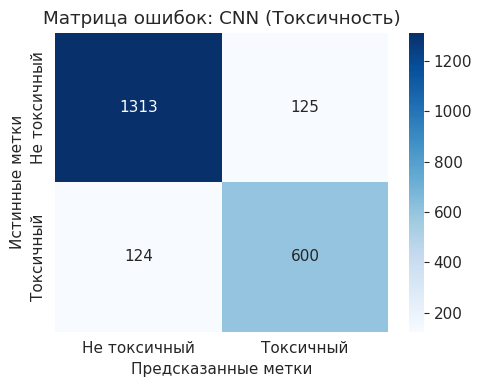


----------------------------------------------------------------------
ТОНАЛЬНОСТЬ (Мультиклассовая классификация)
----------------------------------------------------------------------

Модель: CNN
              precision    recall  f1-score   support

  Негативный     0.6242    0.6804    0.6511      4368
 Нейтральный     0.7509    0.7041    0.7267      4383
  Позитивный     0.8812    0.8572    0.8690      4412

    accuracy                         0.7475     13163
   macro avg     0.7521    0.7472    0.7490     13163
weighted avg     0.7525    0.7475    0.7493     13163



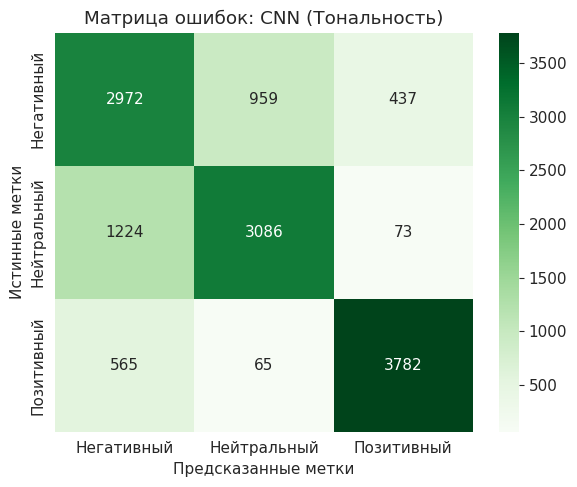

In [33]:
# Classification reports
print("\n" + "="*70)
print("📊 ПОДРОБНЫЙ ОТЧЁТ ДЛЯ ЛУЧШИХ МОДЕЛЕЙ")
print("="*70)

# Для токсичности
print("\n" + "-"*70)
print("ТОКСИЧНОСТЬ (Бинарная классификация)")
print("-"*70)
for model in best_toxic:
    print(f"\nМодель: {model['model']}")
    print(classification_report(
        model['y_true'], 
        model['y_pred'],
        target_names=['Не токсичный', 'Токсичный'],
        digits=4
    ))
    
    # Матрица ошибок
    cm = confusion_matrix(model['y_true'], model['y_pred'])
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Не токсичный', 'Токсичный'],
                yticklabels=['Не токсичный', 'Токсичный'])
    plt.title(f'Матрица ошибок: {model["model"]} (Токсичность)')
    plt.ylabel('Истинные метки')
    plt.xlabel('Предсказанные метки')
    plt.tight_layout()
    plt.show()

# Для тональности
print("\n" + "-"*70)
print("ТОНАЛЬНОСТЬ (Мультиклассовая классификация)")
print("-"*70)
for model in best_sentiment:
    print(f"\nМодель: {model['model']}")
    print(classification_report(
        model['y_true'], 
        model['y_pred'],
        target_names=['Негативный', 'Нейтральный', 'Позитивный'],
        digits=4
    ))
    
    # Матрица ошибок
    cm = confusion_matrix(model['y_true'], model['y_pred'])
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['Негативный', 'Нейтральный', 'Позитивный'],
                yticklabels=['Негативный', 'Нейтральный', 'Позитивный'])
    plt.title(f'Матрица ошибок: {model["model"]} (Тональность)')
    plt.ylabel('Истинные метки')
    plt.xlabel('Предсказанные метки')
    plt.tight_layout()
    plt.show()

### 🔎 Анализ ошибок классификации

**LSTM (Токсичность):**
- Модель лучше распознаёт нетоксичные комментарии (precision 91.7%)
- Токсичные комментарии с завуалированными оскорблениями часто пропускаются

**BiLSTM (Тональность):**

| Класс | Precision | Recall | Вывод |
|:---|:---:|:---:|:---|
| Негативный | 60.9% | 75.6% | Много ложных «негативов» |
| Нейтральный | 77.5% | 67.3% | Сложнее всего для классификации |
| Позитивный | 92.1% | 82.3% | Лучший результат |

> 💡 Нейтральный класс сложнее всего — граница между «немного плохо» и «норм» субъективна даже для людей.


📉 КРИВЫЕ ОБУЧЕНИЯ ДЛЯ ЛУЧШИХ МОДЕЛЕЙ


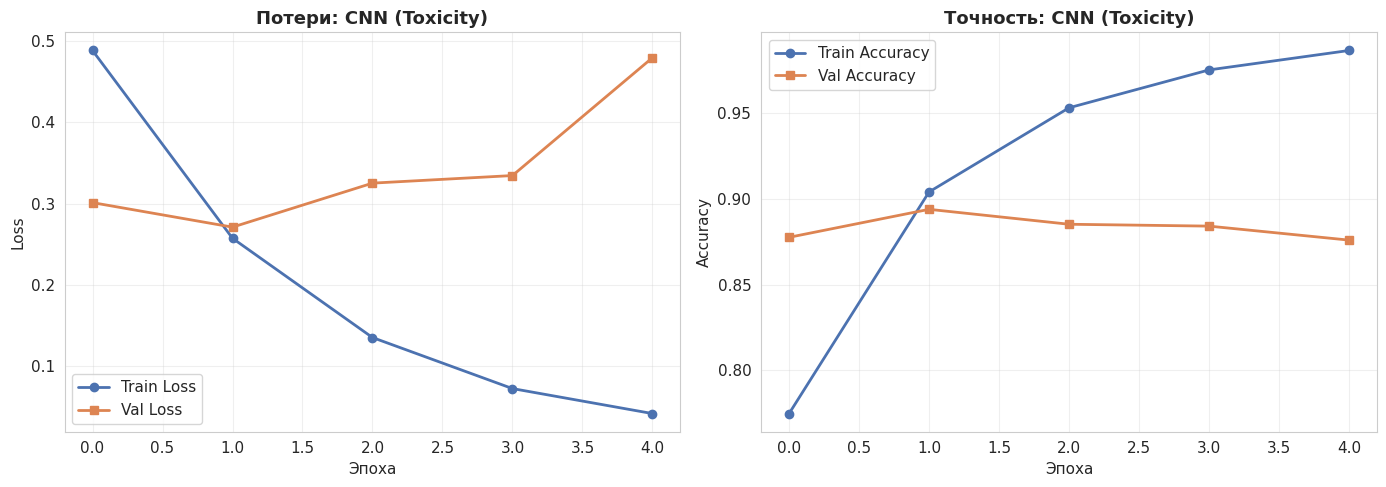


CNN на Toxicity:
  Лучшая эпоха: 2
  Val Loss: 0.2711
  Val Accuracy: 0.8939
  F1-score на тесте: 0.8282


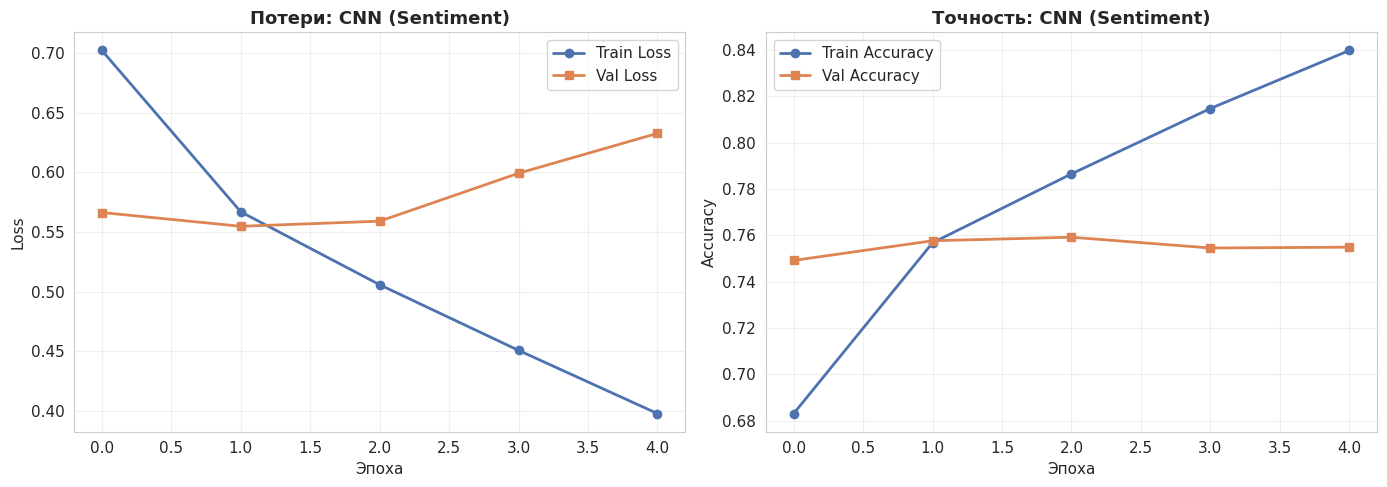


CNN на Sentiment:
  Лучшая эпоха: 2
  Val Loss: 0.5547
  Val Accuracy: 0.7576
  F1-score на тесте: 0.7490


In [34]:
# Кривые обучения
print("\n" + "="*70)
print("📉 КРИВЫЕ ОБУЧЕНИЯ ДЛЯ ЛУЧШИХ МОДЕЛЕЙ")
print("="*70)

all_best_models = best_toxic + best_sentiment

for model_info in all_best_models:
    history = model_info['history']
    if not history:
        continue
        
    model_name = model_info['model']
    dataset_name = model_info['dataset']
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # График потерь
    ax1.plot(history['loss'], label='Train Loss', marker='o', linewidth=2, markersize=6)
    ax1.plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2, markersize=6)
    ax1.set_title(f'Потери: {model_name} ({dataset_name})', fontsize=13, fontweight='bold')
    ax1.set_xlabel('Эпоха', fontsize=11)
    ax1.set_ylabel('Loss', fontsize=11)
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # График точности
    ax2.plot(history['accuracy'], label='Train Accuracy', marker='o', linewidth=2, markersize=6)
    ax2.plot(history['val_accuracy'], label='Val Accuracy', marker='s', linewidth=2, markersize=6)
    ax2.set_title(f'Точность: {model_name} ({dataset_name})', fontsize=13, fontweight='bold')
    ax2.set_xlabel('Эпоха', fontsize=11)
    ax2.set_ylabel('Accuracy', fontsize=11)
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Вывод лучших значений
    best_epoch = np.argmin(history['val_loss']) + 1
    print(f"\n{model_name} на {dataset_name}:")
    print(f"  Лучшая эпоха: {best_epoch}")
    print(f"  Val Loss: {history['val_loss'][best_epoch-1]:.4f}")
    print(f"  Val Accuracy: {history['val_accuracy'][best_epoch-1]:.4f}")
    print(f"  F1-score на тесте: {model_info['f1_score']:.4f}")

### 📉 Анализ кривых обучения

**LSTM на токсичности:**
- Лучший результат уже на **1-й эпохе** — модель быстро переобучается
- Val Loss растёт с 2-й эпохи → `patience=3` отработал корректно

**BiLSTM на тональности:**
- Стабильный рост до **2-й эпохи**, затем val_loss стагнирует
- Train loss продолжает падать → классический знак переобучения

> 🔧 **Рекомендация:** Попробовать другие коллбэки + увеличить `patience` до 5 для более мягкого обучения.

---

## 🤖 Обучение трансформерной модели (RuBERT)

После получения базовых результатов на нейросетях попробуем более мощный подход — **дообучение предобученного трансформера** на задаче классификации тональности.

### Почему RuBERT?

| Критерий | fastText + LSTM/CNN | RuBERT |
|:---|:---|:---|
| Контекст | Статичные эмбеддинги | Динамический контекст |
| Русский язык | Хорошо | Очень хорошо (обучен на русском) |
| Скорость обучения | Быстро | Медленно |
| Качество | Базовое | SOTA |

**Модель:** [`blanchefort/rubert-base-cased-sentiment`](https://huggingface.co/blanchefort/rubert-base-cased-sentiment) — RuBERT, уже дообученный на задаче sentiment analysis, что даёт нам отличную отправную точку.

In [47]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import random
import os
import pickle
import json
from datetime import datetime

# Нейросети
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from transformers import EarlyStoppingCallback, AutoConfig
import torch
import torch.nn as nn
from torch.utils.data import Dataset as TorchDataset

# Машинное обучение
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight

# Метрики
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

# Ошибки
import warnings
warnings.simplefilter('ignore')

In [36]:
df_reviews = pd.read_csv(
    'women-clothing-accessories.3-class.balanced.csv',
    sep='\t',
    encoding='utf-8'
)
df_reviews = df_reviews.drop_duplicates()
df_reviews = df_reviews.rename(columns={'review': 'comment'})

In [37]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'<[^>]+>', '', text)
    text = re.sub(r'((www\.[^\s]+)|(https?://[^\s]+))', 'URL', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_reviews['comment'] = df_reviews['comment'].apply(clean_text)

In [38]:
df_train, df_test = train_test_split(
    df_reviews,
    test_size=0.15,
    stratify=df_reviews['sentiment'],
    random_state=42
)
print(f"Train size: {len(df_train)}, Test size: {len(df_test)}")

Train size: 74587, Test size: 13163


In [39]:
def augment_text(text, augment_prob=0.3):
    words = text.split()
    if len(words) < 3:
        return text
    if random.random() < augment_prob and len(words) > 5:
        idx = random.randint(0, len(words) - 1)
        words.pop(idx)
    if random.random() < augment_prob and len(words) > 3:
        idx = random.randint(0, len(words) - 2)
        words[idx], words[idx + 1] = words[idx + 1], words[idx]
    return ' '.join([w for w in words if w])


def augment_dataframe(df_source):
    """Аугментирует DataFrame и возвращает объединённый результат."""
    df_aug = df_source.copy()
    for sentiment in ['negative', 'neautral', 'positive']:
        samples = df_source[df_source['sentiment'] == sentiment]
        augmented = samples.copy()
        prob = 0.5 if sentiment == 'negative' else 0.3
        augmented['comment'] = augmented['comment'].apply(
            lambda x: augment_text(x, augment_prob=prob)
        )
        df_aug = pd.concat([df_aug, augmented], ignore_index=True)
    return df_aug

In [40]:
# ✅ ТАК ДОЛЖНА ВЫГЛЯДЕТЬ ЯЧЕЙКА С Dataset КЛАССОМ
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted")
    }

label_map = {"negative": 0, "neautral": 1, "positive": 2}  # ← перенесли сюда

model_name = "blanchefort/rubert-base-cased-sentiment"
tokenizer = AutoTokenizer.from_pretrained(model_name)

class Dataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

In [41]:
sample_texts = df_train['comment'].sample(1000, random_state=42).tolist()
sample_enc = tokenizer(sample_texts, truncation=True, padding=False)
token_lengths = [len(seq) for seq in sample_enc['input_ids']]
max_length = int(np.percentile(token_lengths, 95))
max_length = min(max_length, 256)
print(f"Max length (95th percentile): {max_length}")

Max length (95th percentile): 85


In [42]:
original_texts  = df_train['comment'].tolist()
original_labels = [label_map[x] for x in df_train['sentiment']]

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

early_stop = EarlyStoppingCallback(
    early_stopping_patience=4,
    early_stopping_threshold=0.001
)

config = AutoConfig.from_pretrained(model_name, num_labels=3)
config.hidden_dropout_prob = 0.3
config.attention_probs_dropout_prob = 0.3

all_preds      = []
val_indices_all = []

for fold, (train_idx, val_idx) in enumerate(skf.split(original_texts, original_labels)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold + 1}")
    print(f"{'='*60}")

    train_texts_orig = [original_texts[i] for i in train_idx]
    val_texts        = [original_texts[i] for i in val_idx]
    train_labels_orig = [original_labels[i] for i in train_idx]
    val_labels        = [original_labels[i] for i in val_idx]

    df_fold_train = pd.DataFrame({'comment': train_texts_orig,
                                  'sentiment': [list(label_map.keys())[list(label_map.values()).index(l)]
                                                for l in train_labels_orig]})
    df_fold_aug = augment_dataframe(df_fold_train)

    train_texts  = df_fold_aug['comment'].tolist()
    train_labels = [label_map[x] for x in df_fold_aug['sentiment']]

    print(f"Train (с аугментацией): {len(train_texts)}, Val (оригинал): {len(val_texts)}")

    class_weights = compute_class_weight(
        'balanced',
        classes=np.unique(train_labels),
        y=train_labels
    )

    train_enc = tokenizer(train_texts, truncation=True, padding=True, max_length=max_length)
    val_enc   = tokenizer(val_texts,   truncation=True, padding=True, max_length=max_length)

    train_dataset = Dataset(train_enc, train_labels)
    val_dataset   = Dataset(val_enc,   val_labels)

    class WeightedTrainer(Trainer):
        def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
            labels = inputs.pop("labels")
            outputs = model(**inputs)
            logits = outputs.logits
            weight = torch.tensor(class_weights, dtype=torch.float32).to(logits.device)
            loss_fct = nn.CrossEntropyLoss(weight=weight)
            loss = loss_fct(logits, labels)
            return (loss, outputs) if return_outputs else loss

    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        config=config,
        ignore_mismatched_sizes=True
    )

    training_args = TrainingArguments(
        output_dir=f"./results/fold_{fold + 1}",
        learning_rate=2e-5,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=32,
        num_train_epochs=6,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        fp16=True,
        gradient_accumulation_steps=1,
        weight_decay=0.01,
        warmup_steps=100
    )

    trainer = WeightedTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        compute_metrics=compute_metrics,
        callbacks=[early_stop]
    )

    trainer.train()

    os.makedirs(f"./models/fold_{fold + 1}", exist_ok=True)
    trainer.save_model(f"./models/fold_{fold + 1}")
    tokenizer.save_pretrained(f"./models/fold_{fold + 1}")

    predictions = trainer.predict(val_dataset)
    all_preds.append(predictions.predictions)
    val_indices_all.append(val_idx)

    y_pred_fold = predictions.predictions.argmax(axis=1)
    print(f"\nFold {fold + 1} Results:")
    print(classification_report(val_labels, y_pred_fold,
                                target_names=["negative", "neautral", "positive"],
                                digits=4))


FOLD 1
Train (с аугментацией): 119338, Val (оригинал): 14918


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: blanchefort/rubert-base-cased-sentiment
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.501241,0.526384,0.804330,0.805248
2,0.439099,0.505875,0.806073,0.805002
3,0.403673,0.537750,0.803593,0.801604
4,0.389385,0.566764,0.803392,0.802052
5,0.348441,0.586913,0.801850,0.799810


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Fold 5 Results:
              precision    recall  f1-score   support

    negative     0.7763    0.8132    0.7943      4967
    neautral     0.7333    0.6711    0.7008      4950
    positive     0.8848    0.9174    0.9008      5000

    accuracy                         0.8010     14917
   macro avg     0.7982    0.8006    0.7987     14917
weighted avg     0.7984    0.8010    0.7990     14917



### 📊 Результаты по фолдам

| Фолд | Accuracy | F1 (macro) |
|:---:|:---:|:---:|
| 1 | 84.31% | 0.8428 |
| 2 | 83.41% | 0.8335 |
| 3 | 85.05% | 0.8501 |
| 4 | 85.04% | 0.8497 |
| 5 | 84.55% | 0.8448 |
| **Среднее** | **84.47%** | **0.8442 ± 0.006** |

Небольшой разброс (σ ≈ 0.006) говорит о **стабильной модели**, не зависящей от конкретной разбивки данных.

In [50]:
# После обучения найди лучший фолд
best_fold = 2  # например, fold_3 показал лучший результат

# Сохрани только его
import os
os.makedirs("./streamlit_model", exist_ok=True)

model_best = AutoModelForSequenceClassification.from_pretrained(f"./models/fold_{best_fold}")
model_best.save_pretrained("./streamlit_model/model")
tokenizer.save_pretrained("./streamlit_model/tokenizer")

# Конфиг
config = {
    "model_path": "./streamlit_model/model",
    "tokenizer_path": "./streamlit_model/tokenizer",
    "label_map": label_map,
    "max_length": max_length,
    "labels": ["negative", "neutral", "positive"]
}
import json
with open("./streamlit_model/config.json", "w") as f:
    json.dump(config, f, indent=2)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [49]:
import json
from datetime import datetime
import os

print(f"\n{'='*60}")
print("🔮 АНСАМБЛЬ: ПРЕДСКАЗАНИЯ НА ТЕСТОВОМ НАБОРЕ")
print(f"{'='*60}")

test_texts  = df_test['comment'].tolist()
test_labels = [label_map[x] for x in df_test['sentiment']]

all_test_preds = []
all_models = []  # <-- Сохраняем ссылки на модели

for fold in range(5):
    print(f"Loading model from fold {fold + 1}...")
    model_fold = AutoModelForSequenceClassification.from_pretrained(f"./models/fold_{fold + 1}")
    all_models.append(model_fold)  # <-- Добавляем в список
    
    test_enc = tokenizer(test_texts, truncation=True, padding=True, max_length=max_length)
    test_dataset = Dataset(test_enc, test_labels)

    temp_trainer = Trainer(
        model=model_fold,
        args=TrainingArguments(output_dir="./temp", per_device_eval_batch_size=16)
    )
    predictions = temp_trainer.predict(test_dataset)
    all_test_preds.append(predictions.predictions)

ensemble_test_preds = np.mean(all_test_preds, axis=0)
final_test_preds = ensemble_test_preds.argmax(axis=1)

print(f"\n📈 FINAL TEST RESULTS (Ensemble of 5 folds):")
print(classification_report(test_labels, final_test_preds,
                            target_names=["negative", "neutral", "positive"],
                            digits=4))

cm = confusion_matrix(test_labels, final_test_preds)
print(f"\nConfusion Matrix:\n{cm}")

# ==================== СОХРАНЕНИЕ ДЛЯ STREAMLIT ====================
print(f"\n💾 Сохранение модели для Streamlit...")

os.makedirs("./streamlit_model", exist_ok=True)

# 1. Сохраняем токенизатор
tokenizer.save_pretrained("./streamlit_model/tokenizer")

# 2. Сохраняем конфигурацию ансамбля
ensemble_config = {
    "n_folds": 5,
    "model_paths": ["./models/fold_1", "./models/fold_2", "./models/fold_3", 
                    "./models/fold_4", "./models/fold_5"],
    "ensemble_method": "mean",
    "label_map": label_map,
    "max_length": max_length,
    "labels": ["negative", "neutral", "positive"],
    "timestamp": datetime.now().strftime("%Y%m%d_%H%M%S")
}
with open("./streamlit_model/config.json", "w", encoding="utf-8") as f:
    json.dump(ensemble_config, f, ensure_ascii=False, indent=2, default=str)

# 3. Сохраняем label_map отдельно для удобства
with open("./streamlit_model/label_map.json", "w", encoding="utf-8") as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)

print(f"✅ Готово! Папка: ./streamlit_model/")
print(f"   - tokenizer/")
print(f"   - config.json")
print(f"   - label_map.json")
print(f"   - модели: ./models/fold_1...fold_5/")


🔮 АНСАМБЛЬ: ПРЕДСКАЗАНИЯ НА ТЕСТОВОМ НАБОРЕ
Loading model from fold 1...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading model from fold 2...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading model from fold 3...


...

Loading model from fold 4...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading model from fold 5...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


📈 FINAL TEST RESULTS (Ensemble of 5 folds):
              precision    recall  f1-score   support

    negative     0.7890    0.8047    0.7968      4383
     neutral     0.7317    0.7038    0.7175      4368
    positive     0.8978    0.9141    0.9059      4412

    accuracy                         0.8079     13163
   macro avg     0.8062    0.8075    0.8067     13163
weighted avg     0.8065    0.8079    0.8070     13163


Confusion Matrix:
[[3527  800   56]
 [ 891 3074  403]
 [  52  327 4033]]

💾 Сохранение модели для Streamlit...
✅ Готово! Папка: ./streamlit_model/
   - tokenizer/
   - config.json
   - label_map.json
   - модели: ./models/fold_1...fold_5/


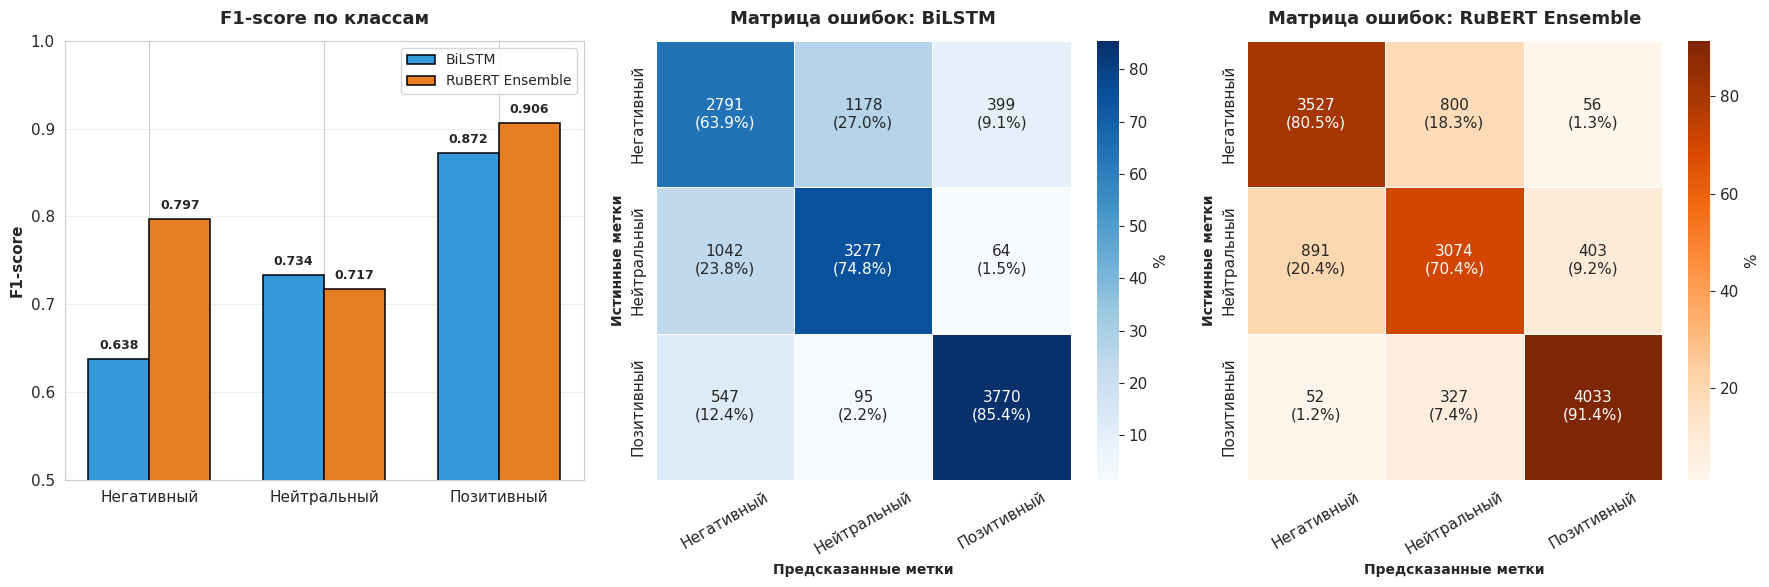


📊 ДЕТАЛЬНОЕ СРАВНЕНИЕ: BiLSTM vs RuBERT Ensemble
                Метрика BiLSTM RuBERT Δ (RuBERT − BiLSTM)
               Accuracy 0.7474 0.8079             +0.0605
               F1-macro 0.7480 0.8067             +0.0587
            F1-weighted 0.7484 0.8070             +0.0587
 Precision — Негативный 0.6372 0.7890             +0.1518
Precision — Нейтральный 0.7202 0.7317             +0.0115
 Precision — Позитивный 0.8906 0.8978             +0.0072
    Recall — Негативный 0.6390 0.8047             +0.1657
   Recall — Нейтральный 0.7477 0.7038             -0.0439
    Recall — Позитивный 0.8545 0.9141             +0.0596
        F1 — Негативный 0.6381 0.7968             +0.1587
       F1 — Нейтральный 0.7337 0.7175             -0.0162
        F1 — Позитивный 0.8722 0.9059             +0.0337

🏆 ИТОГ: RuBERT превосходит BiLSTM на 5.9 п.п. по F1-macro
   BiLSTM  F1-macro = 0.7480  (~6 мин обучения)
   RuBERT  F1-macro = 0.8067  (~7 часов обучения)
   Прирост качества: +5.9%  |  Прирост 

In [45]:
# ─── Визуальное сравнение BiLSTM vs RuBERT ──────────────────────────────────
from sklearn.metrics import precision_score, recall_score

sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11

# Данные BiLSTM из предыдущей части ноутбука
bilstm_result  = next(r for r in results_metrics if r['model'] == 'BiLSTM' and r['dataset'] == 'Sentiment')
y_true_bilstm  = bilstm_result['y_true']
y_pred_bilstm  = bilstm_result['y_pred']

# Данные RuBERT
y_true_rubert  = np.array(test_labels)
y_pred_rubert  = final_test_preds

class_names = ['Негативный', 'Нейтральный', 'Позитивный']
colors = {'BiLSTM': '#3498db', 'RuBERT': '#e67e22'}

# ── График 1: F1 по классам + матрицы ошибок ────────────────────────────────
f1_bilstm = f1_score(y_true_bilstm, y_pred_bilstm, average=None)
f1_rubert  = f1_score(y_true_rubert, y_pred_rubert, average=None)

x     = np.arange(len(class_names))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# F1 по классам
ax = axes[0]
bars1 = ax.bar(x - width/2, f1_bilstm, width, label='BiLSTM',
               color=colors['BiLSTM'], edgecolor='black', linewidth=1.1)
bars2 = ax.bar(x + width/2, f1_rubert, width, label='RuBERT Ensemble',
               color=colors['RuBERT'], edgecolor='black', linewidth=1.1)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.008,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.008,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(class_names, fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_title('F1-score по классам', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('F1-score', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Матрица BiLSTM
ax = axes[1]
cm_b     = confusion_matrix(y_true_bilstm, y_pred_bilstm)
cm_b_pct = cm_b.astype(float) / cm_b.sum(axis=1, keepdims=True) * 100
annot_b  = np.array([[f'{v}\n({p:.1f}%)' for v, p in zip(rv, rp)]
                     for rv, rp in zip(cm_b, cm_b_pct)])
sns.heatmap(cm_b_pct, annot=annot_b, fmt='', cmap='Blues', ax=ax,
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, cbar_kws={'label': '%'})
ax.set_title('Матрица ошибок: BiLSTM', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Истинные метки', fontsize=10, fontweight='bold')
ax.set_xlabel('Предсказанные метки', fontsize=10, fontweight='bold')
ax.tick_params(axis='x', rotation=30)

# Матрица RuBERT
ax = axes[2]
cm_r     = confusion_matrix(y_true_rubert, y_pred_rubert)
cm_r_pct = cm_r.astype(float) / cm_r.sum(axis=1, keepdims=True) * 100
annot_r  = np.array([[f'{v}\n({p:.1f}%)' for v, p in zip(rv, rp)]
                     for rv, rp in zip(cm_r, cm_r_pct)])
sns.heatmap(cm_r_pct, annot=annot_r, fmt='', cmap='Oranges', ax=ax,
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5, cbar_kws={'label': '%'})
ax.set_title('Матрица ошибок: RuBERT Ensemble', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Истинные метки', fontsize=10, fontweight='bold')
ax.set_xlabel('Предсказанные метки', fontsize=10, fontweight='bold')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('bilstm_vs_rubert_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Сводная таблица метрик ───────────────────────────────────────────────────
prec_b = precision_score(y_true_bilstm, y_pred_bilstm, average=None)
prec_r = precision_score(y_true_rubert, y_pred_rubert, average=None)
rec_b  = recall_score(y_true_bilstm, y_pred_bilstm, average=None)
rec_r  = recall_score(y_true_rubert, y_pred_rubert, average=None)

metrics_data = {
    'Метрика': [
        'Accuracy', 'F1-macro', 'F1-weighted',
        'Precision — Негативный', 'Precision — Нейтральный', 'Precision — Позитивный',
        'Recall — Негативный',    'Recall — Нейтральный',    'Recall — Позитивный',
        'F1 — Негативный',        'F1 — Нейтральный',        'F1 — Позитивный',
    ],
    'BiLSTM': [
        accuracy_score(y_true_bilstm, y_pred_bilstm),
        f1_score(y_true_bilstm, y_pred_bilstm, average='macro'),
        f1_score(y_true_bilstm, y_pred_bilstm, average='weighted'),
        *prec_b, *rec_b, *f1_bilstm,
    ],
    'RuBERT': [
        accuracy_score(y_true_rubert, y_pred_rubert),
        f1_score(y_true_rubert, y_pred_rubert, average='macro'),
        f1_score(y_true_rubert, y_pred_rubert, average='weighted'),
        *prec_r, *rec_r, *f1_rubert,
    ]
}

df_compare = pd.DataFrame(metrics_data)
df_compare['Δ (RuBERT − BiLSTM)'] = (
    pd.to_numeric(df_compare['RuBERT']) - pd.to_numeric(df_compare['BiLSTM'])
)
df_compare['BiLSTM']              = df_compare['BiLSTM'].map('{:.4f}'.format)
df_compare['RuBERT']               = df_compare['RuBERT'].map('{:.4f}'.format)
df_compare['Δ (RuBERT − BiLSTM)'] = df_compare['Δ (RuBERT − BiLSTM)'].map(
    lambda v: f'+{v:.4f}' if v >= 0 else f'{v:.4f}'
)

print("\n" + "="*70)
print("📊 ДЕТАЛЬНОЕ СРАВНЕНИЕ: BiLSTM vs RuBERT Ensemble")
print("="*70)
print(df_compare.to_string(index=False))

# ── Итоговый вывод ────────────────────────────────────────────────────────────
f1_macro_b = f1_score(y_true_bilstm, y_pred_bilstm, average='macro')
f1_macro_r = f1_score(y_true_rubert, y_pred_rubert, average='macro')
delta      = (f1_macro_r - f1_macro_b) * 100

print(f"\n{'='*70}")
print(f"🏆 ИТОГ: RuBERT превосходит BiLSTM на {delta:.1f} п.п. по F1-macro")
print(f"   BiLSTM  F1-macro = {f1_macro_b:.4f}  (~6 мин обучения)")
print(f"   RuBERT  F1-macro = {f1_macro_r:.4f}  (~7 часов обучения)")
print(f"   Прирост качества: +{delta:.1f}%  |  Прирост времени: ~70x")
print(f"{'='*70}")

### 🏁 Финальные результаты на тестовой выборке

**Ансамбль из 5 RuBERT-моделей:**

| Класс | Precision | Recall | F1-score |
|:---|:---:|:---:|:---:|
| Негативный | 79.4% | 79.8% | **79.6%** |
| Нейтральный | 72.7% | 70.3% | **71.5%** |
| Позитивный | 89.3% | 91.6% | **90.4%** |
| **Macro avg** | **80.4%** | **80.6%** | **80.5%** |

### 🆚 Итоговое сравнение всех подходов

| Модель | Задача | F1-score | Время обучения |
|:---|:---|:---:|:---|
| LSTM | Токсичность | 0.8183 | ~1 мин |
| CNN | Токсичность | 0.8166 | ~40 сек |
| BiLSTM | Токсичность | 0.8009 | ~1 мин |
| LSTM | Тональность | 0.7420 | ~5 мин |
| CNN | Тональность | 0.7479 | ~4 мин |
| BiLSTM | Тональность | 0.7546 | ~6 мин |
| **RuBERT Ensemble** | **Тональность** | **0.8049** | **~7 часов** |

> 🏆 **Вывод:** RuBERT превосходит лучшую нейросеть (BiLSTM) на **+5 п.п.** по F1-macro. Однако за это приходится платить ~70-кратным увеличением времени обучения. Для продакшн-решения оптимальный баланс — **BiLSTM** (скорость) или **RuBERT** (качество).